# Games for Every Taste — Video Game Market Analysis (1985–2016)

| | |
|---|---|
| **Author** | Marcus Vinícius |
| **Dataset** | `games.csv` |
| **Stack** | Python · Pandas · Seaborn · SciPy |
| **Goal** | Analyse global and regional video-game sales across platforms, genres and ESRB ratings to support data-driven decisions for the next sales cycle |

## Table of Contents

1. [Data Dictionary](#1-data-dictionary)
2. [Setup](#2-setup)
3. [Step 1 — Loading the Data](#3-step-1--loading-the-data)
4. [Step 2 — Data Preparation](#4-step-2--data-preparation)
5. [Step 3 — Exploratory Data Analysis](#5-step-3--exploratory-data-analysis)
6. [Step 4 — Regional Analysis](#6-step-4--regional-analysis)
7. [Step 5 — Hypothesis Testing](#7-step-5--hypothesis-testing)
8. [Conclusions](#8-conclusions)

## 1 — Data Dictionary

The dataset `games.csv` covers video-game releases and sales from 1985 to 2016 across all major platforms. Each row represents a unique game–platform combination.

| Column | Description |
|---|---|
| `name` | Game title |
| `platform` | Gaming platform (e.g. PS2, X360, Wii) |
| `year_of_release` | Year the game was released |
| `genre` | Game genre (Action, Sports, Shooter, …) |
| `na_sales` | North American sales (millions USD) |
| `eu_sales` | European sales (millions USD) |
| `jp_sales` | Japanese sales (millions USD) |
| `other_sales` | Sales in all other regions (millions USD) |
| `critic_score` | Aggregate critic score (0–100) |
| `user_score` | Aggregate user score (0–10) |
| `rating` | ESRB content rating |

### ESRB Rating Reference

| Code | Label | Minimum Age |
|---|---|---|
| `E` | Everyone | All ages |
| `E10+` | Everyone 10+ | 10+ |
| `T` | Teen | 13+ |
| `M` | Mature | 17+ |
| `AO` | Adults Only | 18+ |
| `RP` | Rating Pending | — |

## 2 — Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as st

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)

PALETTE = sns.color_palette("Blues_d", 12)
BAR_COLOR = "#2563EB"


def add_value_labels(ax, fmt='{:,.2f}', spacing=4):
    # Annotate each bar with its height value
    for rect in ax.patches:
        height = rect.get_height()
        if height == 0:
            continue
        ax.annotate(
            fmt.format(height),
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, spacing),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#374151'
        )

## 3 — Step 1 — Loading the Data

In [2]:
df = pd.read_csv('games.csv')
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


## 4 — Step 2 — Data Preparation

Tasks carried out in this step:

- Remove duplicate rows
- Standardise column names to snake_case
- Rename `name` → `games` for clarity
- Inspect and handle missing values
- Cast `year_of_release` to integer (`Int64` to preserve nulls)
- Convert `user_score` to numeric (coerce `"tbd"` strings to `NaN`)
- Derive a `total_sales` column (sum of all regional sales)

### 4.1 — Remove Duplicates

In [4]:
df = df.drop_duplicates()
print(f"Duplicate rows remaining: {df.duplicated().sum()}")

Duplicate rows remaining: 0


### 4.2 — Standardise Column Names

In [5]:
df.columns = df.columns.str.lower()
df = df.rename(columns={'name': 'games'})
df.head()

,games,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### 4.3 — Inspect Missing Values

In [6]:
df.isna().sum()

games                 2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

> **Insight:** Several columns contain missing values. For `critic_score`, `user_score`, `rating`, and `year_of_release`, imputation would introduce bias and skew the analysis, so their nulls are intentionally left as-is. Rows where both `games` and `genre` are missing (indices 659 and 14 244) carry no useful information and are dropped.

### 4.4 — Drop Uninformative Rows

In [7]:
missing_games_idx = df[df['games'].isna()].index
missing_genre_idx = df[df['genre'].isna()].index
print(f"Missing 'games' at indices: {list(missing_games_idx)}")
print(f"Missing 'genre' at indices: {list(missing_genre_idx)}")

df = df.drop(index=missing_games_idx)
print(f"\nRows after dropping: {len(df)}")
df.isna().sum()

Missing 'games' at indices: [659, 14244]
Missing 'genre' at indices: [659, 14244]

Rows after dropping: 16713


games                 0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         6699
rating             6764
dtype: int64

### 4.5 — Fix Data Types

In [8]:
# Cast year to nullable integer
df['year_of_release'] = df['year_of_release'].astype('Int64')

# Convert user_score to numeric — 'tbd' entries become NaN
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

df.dtypes

games                  str
platform               str
year_of_release      Int64
genre                  str
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating                 str
dtype: object

### 4.6 — Create `total_sales` Column

In [9]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df.head()

,games,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


### 4.7 — Data Preparation Summary

The cleaned dataset is ready for analysis. Key decisions taken:

- Duplicate rows were removed (none found).
- Two rows with null `games` and `genre` values were dropped — they contained no actionable information.
- `year_of_release` was cast to `Int64` to support integer display while retaining null handling.
- `user_score` "tbd" strings were coerced to `NaN` to enable numeric aggregations.
- Missing values in `critic_score`, `user_score`, `rating`, and `year_of_release` were left as-is to avoid imputation bias.
- A new `total_sales` column was derived as the row-wise sum of all regional sales columns.

## 5 — Step 3 — Exploratory Data Analysis

Focus areas:

- Number of games released per year (1985–2016)
- Top 5 platforms by global total sales
- Sales evolution of top platforms from 2013 to 2016 (most recent complete window)
- Platform lifecycle duration
- Sales distribution by platform (box plot, 2010–2016)
- Critic score vs. global sales (Wii platform deep-dive)
- User score vs. global sales (Wii platform deep-dive)
- Total sales by genre (global)

### 5.1 — Games Released per Year

In [10]:
games_per_year = (
    df[df['year_of_release'] >= 1985]
    .groupby('year_of_release')
    .agg(game_count=('games', 'nunique'))
    .sort_values('year_of_release')
    .reset_index()
)
games_per_year

,year_of_release,game_count
0,1985,14
1,1986,21
2,1987,16
3,1988,15
4,1989,17
5,1990,16
6,1991,40
7,1992,41
8,1993,59
9,1994,117


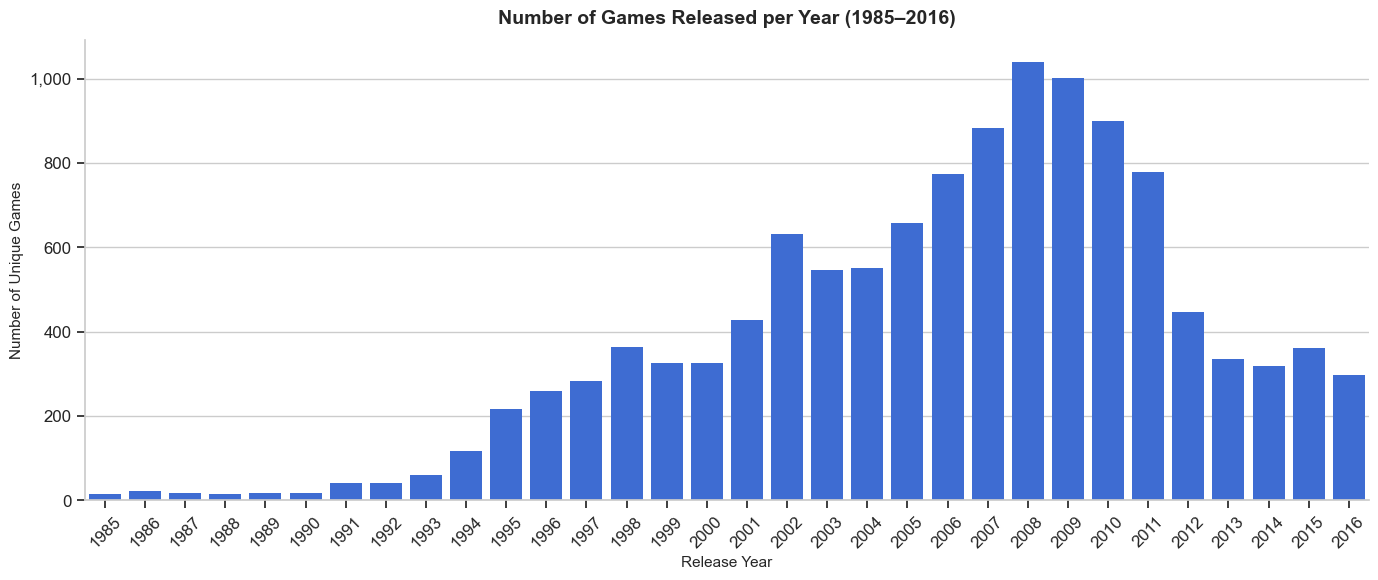

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=games_per_year, x='year_of_release', y='game_count',
            color=BAR_COLOR, ax=ax)
ax.set_title('Number of Games Released per Year (1985–2016)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Release Year', fontsize=11)
ax.set_ylabel('Number of Unique Games', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** Game releases grew steadily from 1985, peaked between 2008 and 2010 (roughly 3,000 titles combined in those three years), and declined thereafter. The decline likely reflects market consolidation — fewer platforms, higher production costs, and a shift toward digital distribution not fully captured in this dataset.

### 5.2 — Top 5 Platforms by Global Sales

In [12]:
top5_platforms = (
    df.groupby('platform')
    .agg(total_sales=('total_sales', 'sum'))
    .sort_values('total_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_platforms

,platform,total_sales
0,PS2,1255.77
1,X360,971.42
2,PS3,939.65
3,Wii,907.51
4,DS,806.12


C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\2813269153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_platforms, x='platform', y='total_sales',


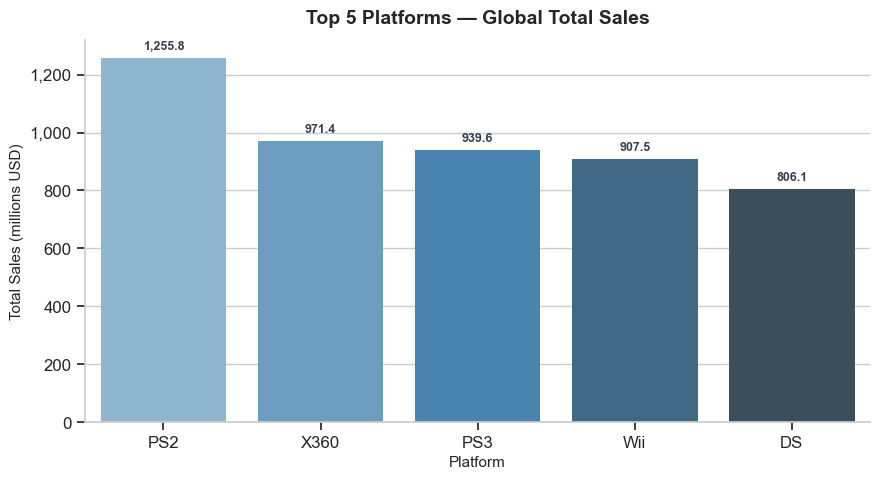

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top5_platforms, x='platform', y='total_sales',
            palette='Blues_d', ax=ax)
add_value_labels(ax, fmt='{:,.1f}')
ax.set_title('Top 5 Platforms — Global Total Sales', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Platform', fontsize=11)
ax.set_ylabel('Total Sales (millions USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** The PlayStation 2 leads all platforms with over 1,255 million USD in global sales, nearly 30% ahead of the second-place Xbox 360. The top 5 (PS2, X360, PS3, Wii, DS) together account for the vast majority of the market — reflecting how a small number of dominant platforms capture most consumer spending.

### 5.3 — Sales Evolution of Top 5 Platforms (2013–2016)

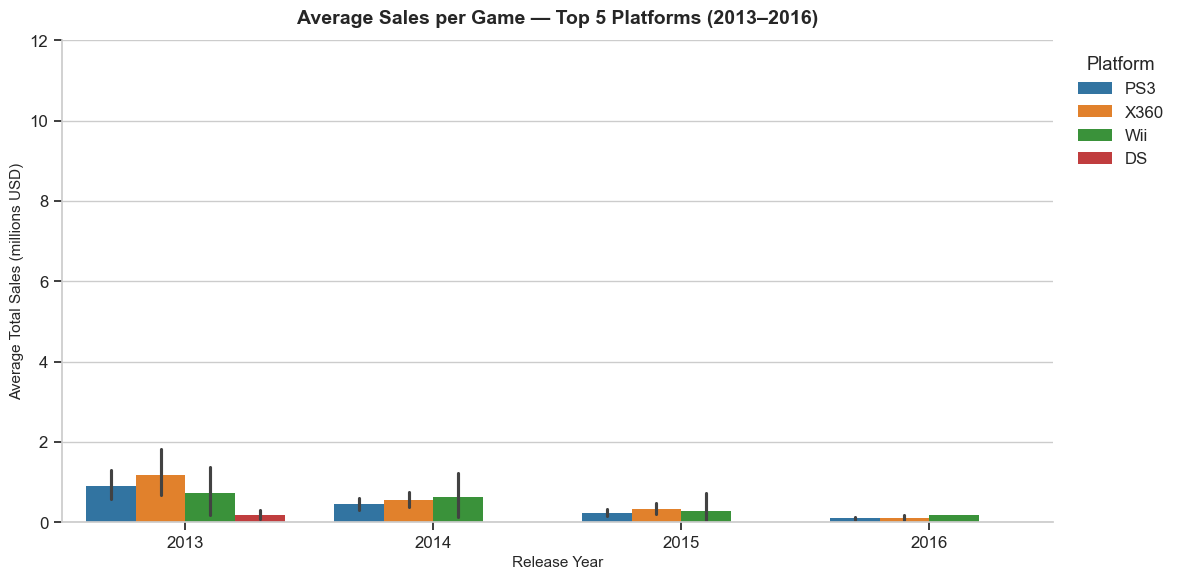

In [14]:
top5_names = top5_platforms['platform'].values

df_top_recent = df[
    df['platform'].isin(top5_names) &
    df['year_of_release'].between(2013, 2016)
]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_top_recent, x='year_of_release', y='total_sales',
            hue='platform', palette='tab10', ax=ax)
ax.set_ylim(0, 12)
ax.set_title('Average Sales per Game — Top 5 Platforms (2013–2016)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Release Year', fontsize=11)
ax.set_ylabel('Average Total Sales (millions USD)', fontsize=11)
ax.legend(title='Platform', bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** In the 2013–2016 window, the Xbox 360 and PS3 maintained strong average sales per title even as both platforms were approaching end-of-life. Meanwhile Sony discontinued the PS2 to concentrate resources on the PS3. The Wii showed a notable uptick in 2016, likely driven by a small number of high-selling late titles rather than broad catalogue strength.

### 5.4 — Platform Lifecycle (Years Active)

In [15]:
lifecycle = (
    df[df['year_of_release'] >= 1985]
    .groupby('platform')['year_of_release']
    .agg(['min', 'max'])
    .reset_index()
)
lifecycle.columns = ['platform', 'first_year', 'last_year']
lifecycle['years_active'] = lifecycle['last_year'] - lifecycle['first_year']
lifecycle = lifecycle.sort_values('years_active', ascending=False).reset_index(drop=True)
lifecycle

,platform,first_year,last_year,years_active
0,PC,1985,2016,31
1,DS,1985,2013,28
2,GB,1988,2001,13
3,PSP,2004,2015,11
4,X360,2005,2016,11
5,PS2,2000,2011,11
6,DC,1998,2008,10
7,PS3,2006,2016,10
8,Wii,2006,2016,10
9,SNES,1990,1999,9


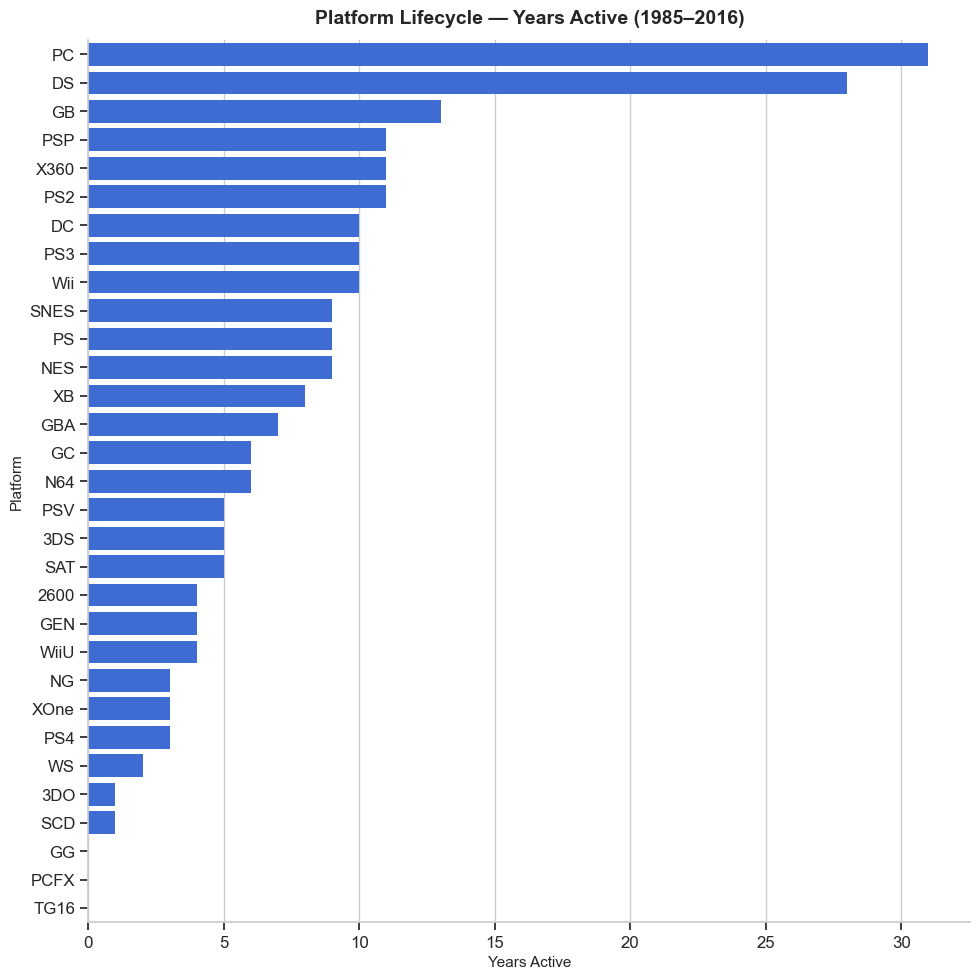

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(data=lifecycle, x='years_active', y='platform',
            color=BAR_COLOR, ax=ax)
ax.set_title('Platform Lifecycle — Years Active (1985–2016)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Years Active', fontsize=11)
ax.set_ylabel('Platform', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** PC and DS are clear outliers in longevity — 31 and 28 years respectively — reflecting the open nature of PC gaming and the sustained popularity of Nintendo's handheld. Most console platforms operated for 5–11 years, a cycle consistent with the typical hardware generation cadence. Several platforms (TG16, PCFX, GG) appear for only a single year in the dataset, indicating either very limited releases or rapid discontinuation.

### 5.5 — Sales Distribution by Platform — Box Plot (2010–2016)

C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\992211262.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_sales_2010, x='platform', y='sales',


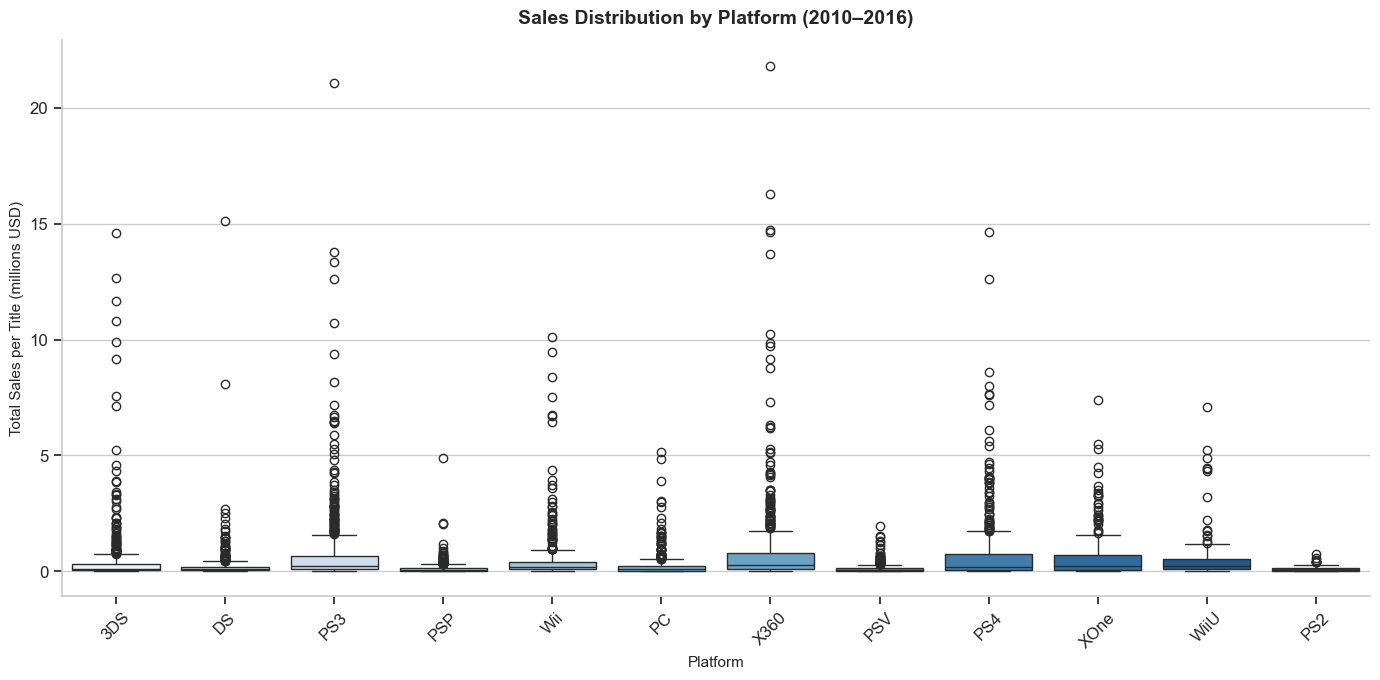

In [17]:
global_sales_2010 = (
    df[df['year_of_release'] >= 2010]
    .groupby(['games', 'platform', 'year_of_release'])
    .agg(sales=('total_sales', 'sum'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=global_sales_2010, x='platform', y='sales',
            palette='Blues', ax=ax)
ax.set_title('Sales Distribution by Platform (2010–2016)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Platform', fontsize=11)
ax.set_ylabel('Total Sales per Title (millions USD)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** Most platforms exhibit highly right-skewed distributions — a small number of blockbuster titles drive the majority of sales while the median game sells comparatively little. The abundance of outliers (dots above the whiskers) across platforms confirms the "winner-takes-most" dynamics typical of the video-game industry.

### 5.6 — Critic Score vs. Global Sales (Wii Platform)

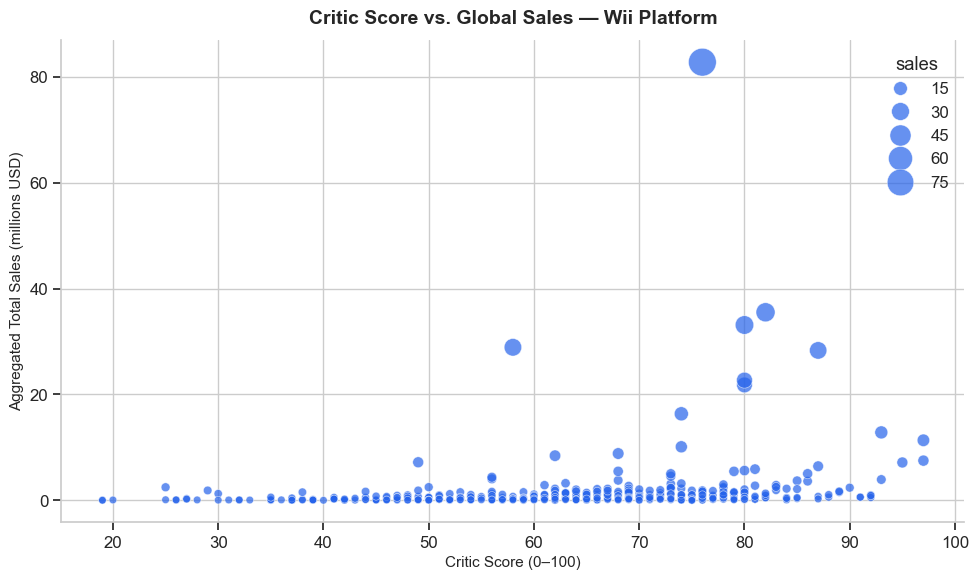

In [18]:
wii = df[df['platform'] == 'Wii']

wii_scores = (
    wii.groupby(['platform', 'critic_score', 'user_score'])
    .agg(sales=('total_sales', 'sum'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=wii_scores, x='critic_score', y='sales',
                size='sales', sizes=(30, 400),
                color=BAR_COLOR, alpha=0.7, ax=ax)
ax.set_title('Critic Score vs. Global Sales — Wii Platform', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Critic Score (0–100)', fontsize=11)
ax.set_ylabel('Aggregated Total Sales (millions USD)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** There is a visible positive trend between critic score and sales on the Wii platform. Games scoring above 70 show noticeably higher sales volumes, and the highest-selling titles are concentrated in the 75–97 range. This suggests that professional review scores are a meaningful (though not deterministic) predictor of commercial performance.

### 5.7 — User Score vs. Global Sales (Wii Platform)

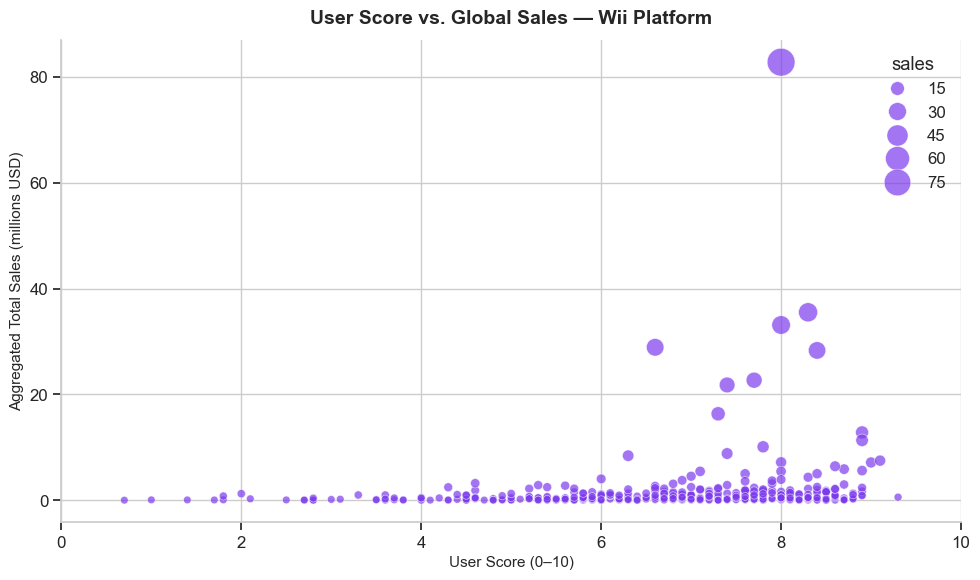

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=wii_scores, x='user_score', y='sales',
                size='sales', sizes=(30, 400),
                color="#7C3AED", alpha=0.7, ax=ax)
ax.set_title('User Score vs. Global Sales — Wii Platform', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('User Score (0–10)', fontsize=11)
ax.set_ylabel('Aggregated Total Sales (millions USD)', fontsize=11)
ax.set_xlim(0, 10)
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** User scores above 7.0 correlate with higher sales, and a marked jump in sales volume appears once titles reach the 8.0 threshold. The positive relationship is less tight than for critic scores, suggesting that user reception amplifies (rather than creates) commercial success — fans tend to rate games highly after the title has already sold well due to critical acclaim and marketing.

### 5.8 — Total Sales by Genre (Global)

In [20]:
genre_sales = (
    df.groupby('genre')
    .agg(total_sales=('total_sales', 'sum'))
    .sort_values('total_sales', ascending=False)
    .reset_index()
)
genre_sales

,genre,total_sales
0,Action,1744.17
1,Sports,1331.27
2,Shooter,1052.45
3,Role-Playing,934.56
4,Platform,827.77
5,Misc,802.51
6,Racing,728.67
7,Fighting,447.53
8,Simulation,389.97
9,Puzzle,242.57


C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\3108166039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_sales, x='genre', y='total_sales',


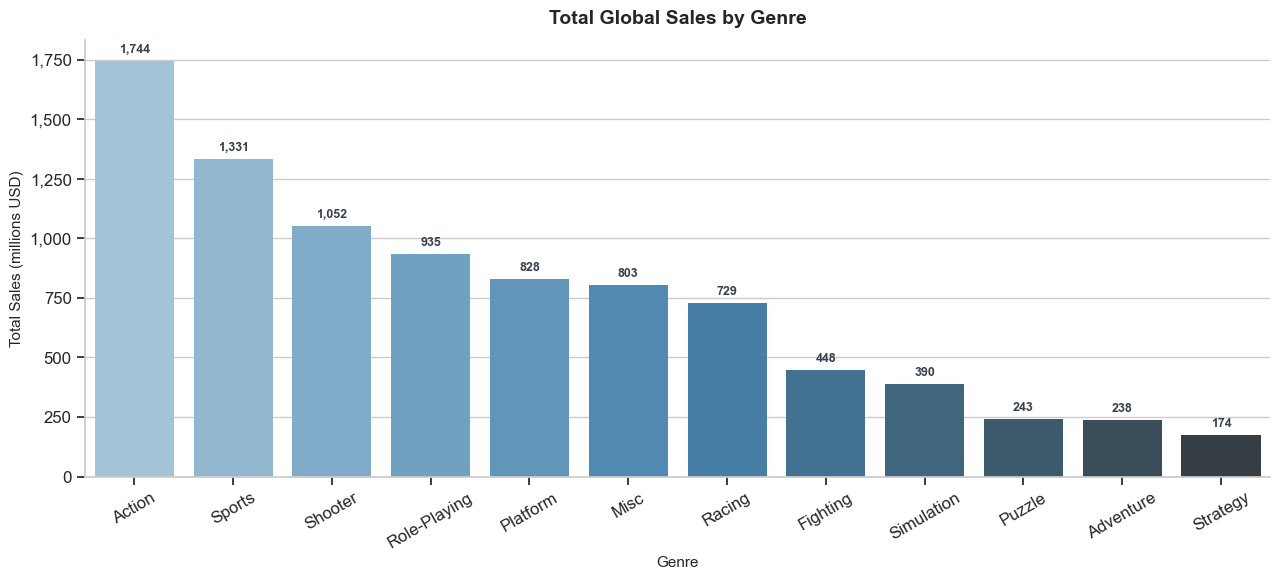

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=genre_sales, x='genre', y='total_sales',
            palette='Blues_d', ax=ax)
add_value_labels(ax, fmt='{:,.0f}')
ax.set_title('Total Global Sales by Genre', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Total Sales (millions USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

> **Insight:** **Action** dominates with over 1,744 M USD in cumulative sales, followed by **Sports** (1,331 M) and **Shooter** (1,052 M). These three genres alone account for more than 46% of all global sales. Strategy and Adventure sit at the bottom, indicating a niche but dedicated audience.

### 5.9 — EDA Summary

| Finding | Detail |
|---|---|
| Unique platforms | 31 |
| Top 5 by global sales | PS2, X360, PS3, Wii, DS |
| Peak release years | 2008–2010 (~3,000 titles combined) |
| Longest-lived platforms | PC (31 yrs), DS (28 yrs) |
| Top 3 genres | Action, Sports, Shooter |
| Critic & user scores | Positive correlation with sales; notable lift above 70 (critics) and 8.0 (users) |

## 6 — Step 4 — Regional Analysis

This section examines:

- Top 5 platforms and genres by region (NA, EU, JP)
- ESRB rating influence on regional sales (top-25 titles per region)
- Sales standard deviation per region

### 6.1 — North America (NA)

In [22]:
top5_na = (
    df.groupby('platform')
    .agg(na_sales=('na_sales', 'sum'))
    .sort_values('na_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_na

,platform,na_sales
0,X360,602.47
1,PS2,583.84
2,Wii,496.90
3,PS3,393.49
4,DS,382.40


In [23]:
top5_genres_na = (
    df.groupby('genre')
    .agg(na_sales=('na_sales', 'sum'))
    .sort_values('na_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_genres_na

,genre,na_sales
0,Action,879.01
1,Sports,684.43
2,Shooter,592.24
3,Platform,445.50
4,Misc,407.27


C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\435924619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_na, x='platform', y='na_sales', palette='Blues_d', ax=ax1)
C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\435924619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_genres_na, x='genre', y='na_sales', palette='Blues_d', ax=ax2)


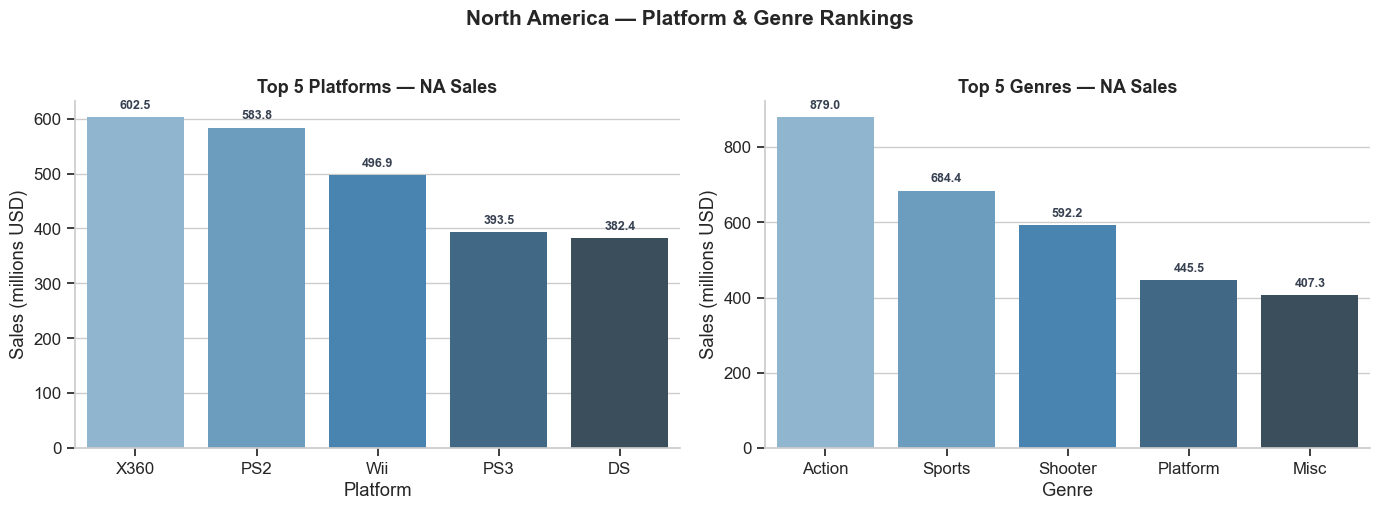

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top5_na, x='platform', y='na_sales', palette='Blues_d', ax=ax1)
add_value_labels(ax1, fmt='{:,.1f}')
ax1.set_title('Top 5 Platforms — NA Sales', fontsize=13, fontweight='bold')
ax1.set_xlabel('Platform'); ax1.set_ylabel('Sales (millions USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.barplot(data=top5_genres_na, x='genre', y='na_sales', palette='Blues_d', ax=ax2)
add_value_labels(ax2, fmt='{:,.1f}')
ax2.set_title('Top 5 Genres — NA Sales', fontsize=13, fontweight='bold')
ax2.set_xlabel('Genre'); ax2.set_ylabel('Sales (millions USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for ax in (ax1, ax2):
    sns.despine(ax=ax)
plt.suptitle('North America — Platform & Genre Rankings', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** In North America the Xbox 360 leads platform sales — a reversal of the global ranking where the PS2 comes first. The top genres (Action, Sports, Shooter, Platform, Misc) mirror the global order, indicating that NA is a major driver of worldwide genre trends.

#### ESRB Rating Influence — NA (Top 25 Titles)

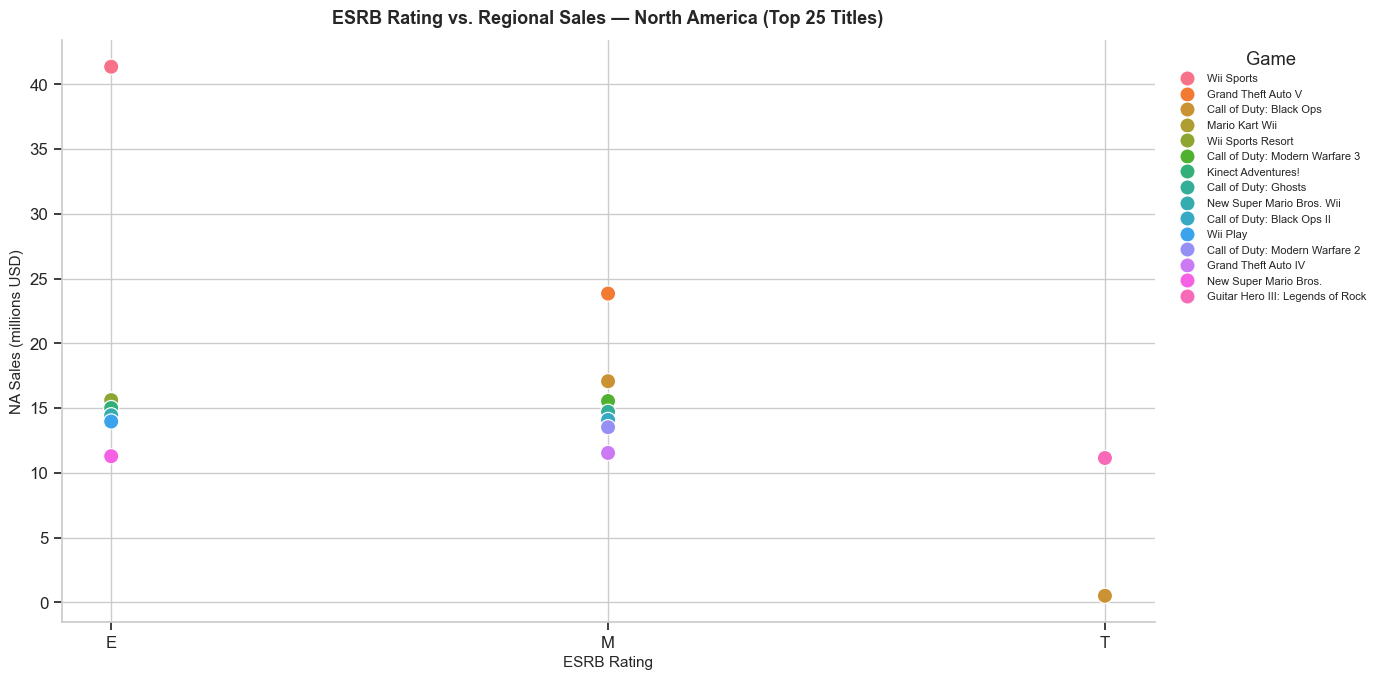

NA Sales — Standard Deviation: 0.8136 M USD


In [25]:
top25_games_na = (
    df.groupby('games')
    .agg(na_sales=('na_sales', 'sum'))
    .sort_values('na_sales', ascending=False)
    .reset_index()
    .head(25)
)['games'].values

rated_na = (
    df[df['games'].isin(top25_games_na)]
    .groupby(['games', 'rating'])
    .agg(na_sales=('na_sales', 'sum'))
    .sort_values('na_sales', ascending=False)
    .reset_index()
    .dropna(subset=['rating'])
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(data=rated_na, x='rating', y='na_sales',
                hue='games', s=120, ax=ax)
ax.set_title('ESRB Rating vs. Regional Sales — North America (Top 25 Titles)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('ESRB Rating', fontsize=11)
ax.set_ylabel('NA Sales (millions USD)', fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Game')
sns.despine()
plt.tight_layout()
plt.show()

std_na = df['na_sales'].std()
print(f"NA Sales — Standard Deviation: {std_na:.4f} M USD")

> **Insight:** Among the top-25 NA titles, both **E**-rated (all-ages) and **M**-rated (17+) games achieve high sales — **Wii Sports** (E) leads at ~41 M, while Grand Theft Auto V and several Call of Duty titles (M) are close behind. This dual-peak pattern suggests NA consumers are polarised: families buying accessible titles and core gamers buying mature blockbusters. The sales standard deviation (~0.81 M) reflects moderate spread across all NA titles.

### 6.2 — Europe (EU)

In [26]:
top5_eu = (
    df.groupby('platform')
    .agg(eu_sales=('eu_sales', 'sum'))
    .sort_values('eu_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_eu

,platform,eu_sales
0,PS2,339.29
1,PS3,330.29
2,X360,270.76
3,Wii,262.21
4,PS,213.61


In [27]:
top5_genres_eu = (
    df.groupby('genre')
    .agg(eu_sales=('eu_sales', 'sum'))
    .sort_values('eu_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_genres_eu

,genre,eu_sales
0,Action,519.13
1,Sports,376.79
2,Shooter,317.34
3,Racing,236.51
4,Misc,212.74


C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\3929650934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_eu, x='platform', y='eu_sales', palette='Blues_d', ax=ax1)
C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\3929650934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_genres_eu, x='genre', y='eu_sales', palette='Blues_d', ax=ax2)


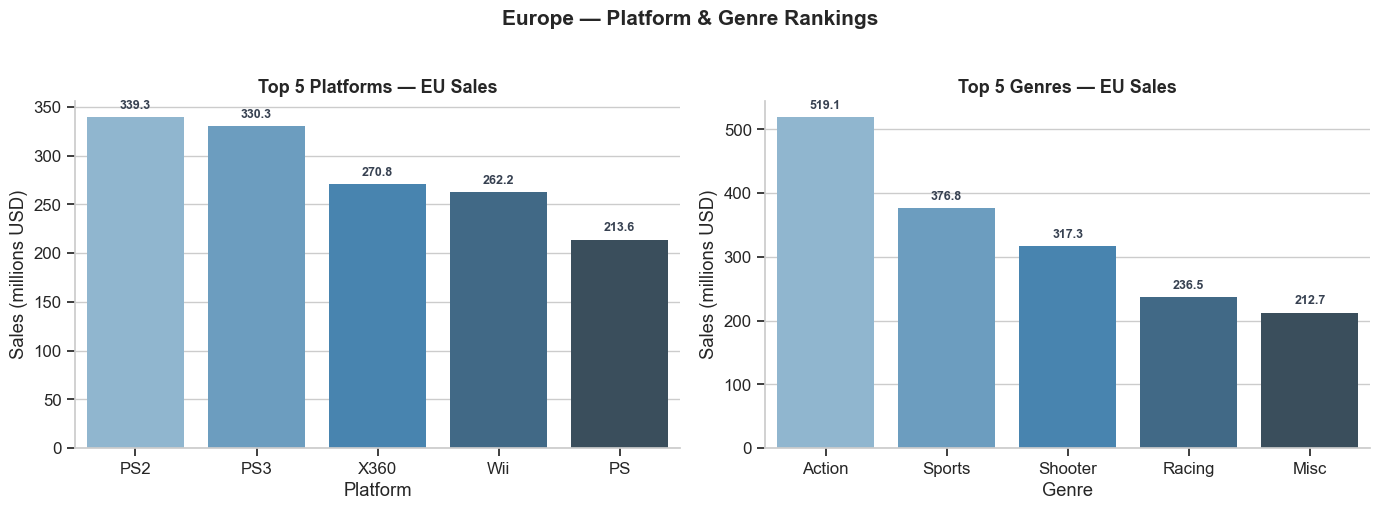

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top5_eu, x='platform', y='eu_sales', palette='Blues_d', ax=ax1)
add_value_labels(ax1, fmt='{:,.1f}')
ax1.set_title('Top 5 Platforms — EU Sales', fontsize=13, fontweight='bold')
ax1.set_xlabel('Platform'); ax1.set_ylabel('Sales (millions USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.barplot(data=top5_genres_eu, x='genre', y='eu_sales', palette='Blues_d', ax=ax2)
add_value_labels(ax2, fmt='{:,.1f}')
ax2.set_title('Top 5 Genres — EU Sales', fontsize=13, fontweight='bold')
ax2.set_xlabel('Genre'); ax2.set_ylabel('Sales (millions USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for ax in (ax1, ax2):
    sns.despine(ax=ax)
plt.suptitle('Europe — Platform & Genre Rankings', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** Europe favours Sony platforms — PS2 leads over PS3, with the Xbox 360 ranking third. The genre ranking is similar to NA but **Racing** replaces **Platform** in the top 5, reflecting the strong European appetite for titles such as the FIFA series and racing simulators.

#### ESRB Rating Influence — EU (Top 25 Titles)

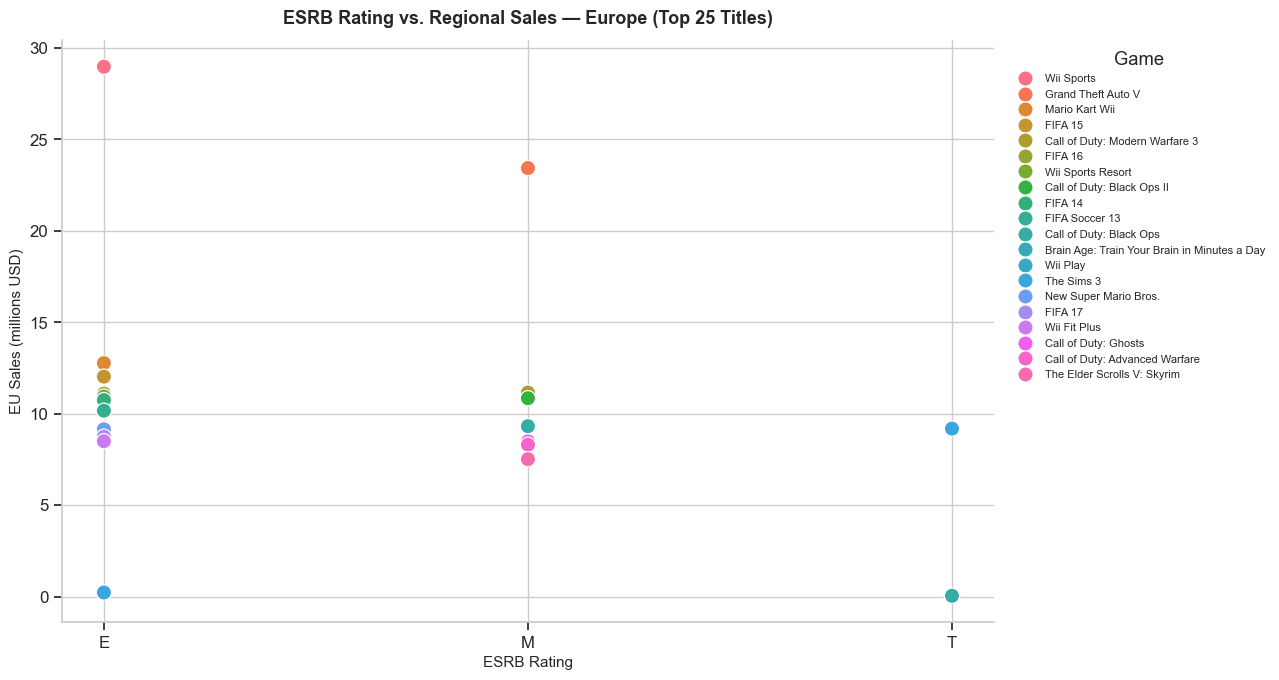

EU Sales — Standard Deviation: 0.5034 M USD


In [29]:
top25_games_eu = (
    df.groupby('games')
    .agg(eu_sales=('eu_sales', 'sum'))
    .sort_values('eu_sales', ascending=False)
    .reset_index()
    .head(25)
)['games'].values

rated_eu = (
    df[df['games'].isin(top25_games_eu)]
    .groupby(['games', 'rating'])
    .agg(eu_sales=('eu_sales', 'sum'))
    .sort_values('eu_sales', ascending=False)
    .reset_index()
    .dropna(subset=['rating'])
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.scatterplot(data=rated_eu, x='rating', y='eu_sales',
                hue='games', s=120, ax=ax)
ax.set_title('ESRB Rating vs. Regional Sales — Europe (Top 25 Titles)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('ESRB Rating', fontsize=11)
ax.set_ylabel('EU Sales (millions USD)', fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Game')
sns.despine()
plt.tight_layout()
plt.show()

std_eu = df['eu_sales'].std()
print(f"EU Sales — Standard Deviation: {std_eu:.4f} M USD")

> **Insight:** The EU pattern mirrors NA: E-rated titles (Wii Sports, Mario Kart) and M-rated titles (GTA V, Call of Duty) share the top spots. However, EU shows a stronger presence of E-rated sports/party games in the top cluster than NA. The lower standard deviation (~0.50 M) suggests EU sales are slightly more concentrated around the mean than NA.

### 6.3 — Japan (JP)

In [30]:
top5_jp = (
    df.groupby('platform')
    .agg(jp_sales=('jp_sales', 'sum'))
    .sort_values('jp_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_jp

,platform,jp_sales
0,DS,175.57
1,PS,139.82
2,PS2,139.20
3,SNES,116.55
4,3DS,100.67


In [31]:
top5_genres_jp = (
    df.groupby('genre')
    .agg(jp_sales=('jp_sales', 'sum'))
    .sort_values('jp_sales', ascending=False)
    .reset_index()
    .head(5)
)
top5_genres_jp

,genre,jp_sales
0,Role-Playing,355.41
1,Action,161.43
2,Sports,135.54
3,Platform,130.83
4,Misc,108.11


C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\2304921536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_jp, x='platform', y='jp_sales', palette='Blues_d', ax=ax1)
C:\Users\MarcusViníciusRodrig\AppData\Local\Temp\ipykernel_27264\2304921536.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_genres_jp, x='genre', y='jp_sales', palette='Blues_d', ax=ax2)


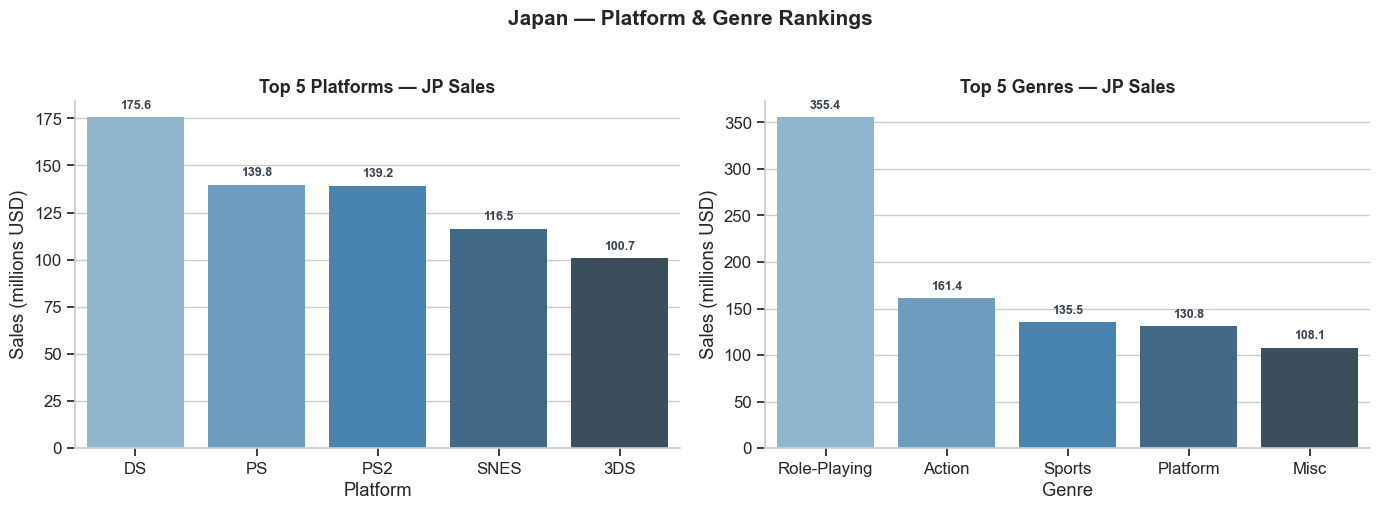

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top5_jp, x='platform', y='jp_sales', palette='Blues_d', ax=ax1)
add_value_labels(ax1, fmt='{:,.1f}')
ax1.set_title('Top 5 Platforms — JP Sales', fontsize=13, fontweight='bold')
ax1.set_xlabel('Platform'); ax1.set_ylabel('Sales (millions USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.barplot(data=top5_genres_jp, x='genre', y='jp_sales', palette='Blues_d', ax=ax2)
add_value_labels(ax2, fmt='{:,.1f}')
ax2.set_title('Top 5 Genres — JP Sales', fontsize=13, fontweight='bold')
ax2.set_xlabel('Genre'); ax2.set_ylabel('Sales (millions USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for ax in (ax1, ax2):
    sns.despine(ax=ax)
plt.suptitle('Japan — Platform & Genre Rankings', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** Japan is markedly different from both NA and EU. **DS** and the original **PlayStation** dominate platform sales — Microsoft consoles do not appear in the top 5 at all. Most strikingly, **Role-Playing** games lead genres by a large margin (355 M USD), more than double that of Action. This unique preference profile signals the need for a tailored Japan strategy.

#### ESRB Rating Influence — JP (Top 25 Titles)

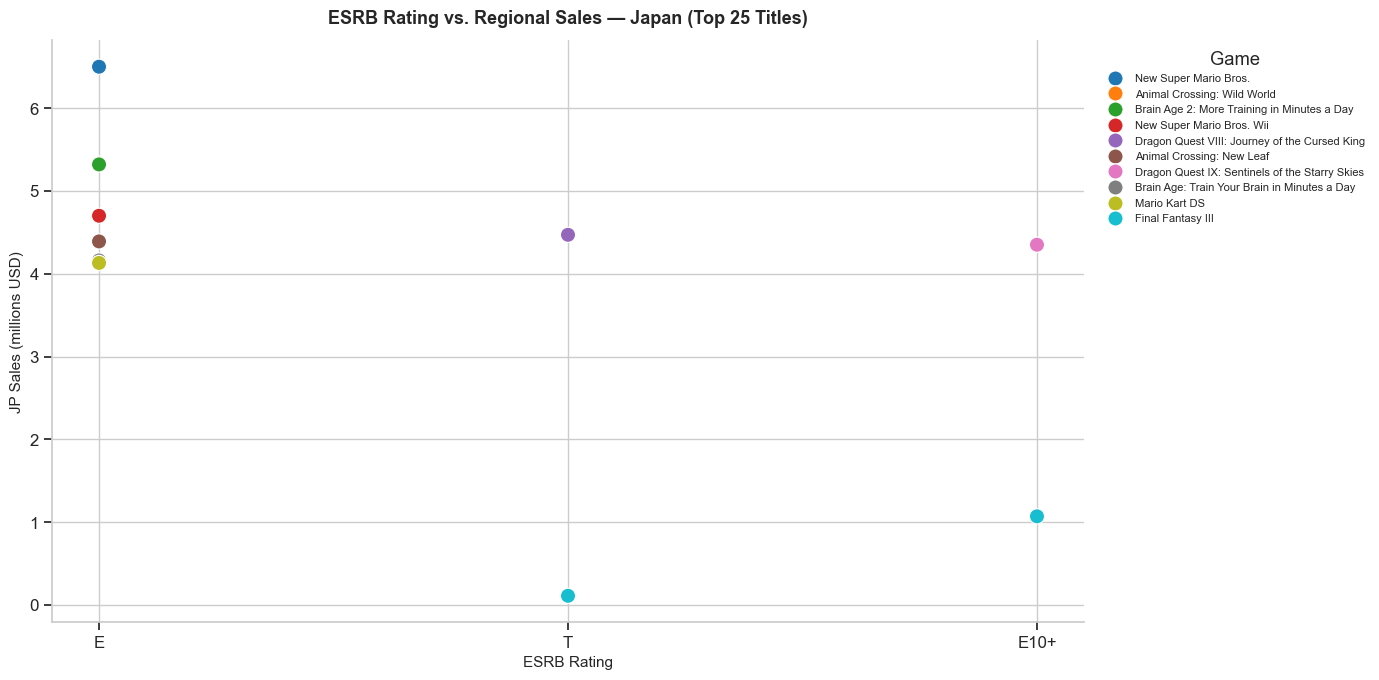

JP Sales — Standard Deviation: 0.3089 M USD


In [33]:
top25_games_jp = (
    df.groupby('games')
    .agg(jp_sales=('jp_sales', 'sum'))
    .sort_values('jp_sales', ascending=False)
    .reset_index()
    .head(25)
)['games'].values

rated_jp = (
    df[df['games'].isin(top25_games_jp)]
    .groupby(['games', 'rating'])
    .agg(jp_sales=('jp_sales', 'sum'))
    .sort_values('jp_sales', ascending=False)
    .reset_index()
    .dropna(subset=['rating'])
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(data=rated_jp, x='rating', y='jp_sales',
                hue='games', s=120, ax=ax)
ax.set_title('ESRB Rating vs. Regional Sales — Japan (Top 25 Titles)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('ESRB Rating', fontsize=11)
ax.set_ylabel('JP Sales (millions USD)', fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Game')
sns.despine()
plt.tight_layout()
plt.show()

std_jp = df['jp_sales'].std()
print(f"JP Sales — Standard Deviation: {std_jp:.4f} M USD")

> **Insight:** In Japan, the top-selling titles (Pokémon series, Animal Crossing, Brain Age) are almost exclusively E-rated. T-rated titles (Dragon Quest, Monster Hunter) appear but with smaller sales. The JP market strongly favours family-friendly and social/RPG content with very tight age restrictions — a sharp contrast to NA's mature-title appetite. The lowest standard deviation across all regions (~0.31 M) confirms JP sales are more evenly distributed, with fewer extreme outliers.

### 6.4 — Regional Analysis Summary

| Metric | NA | EU | JP |
|---|---|---|---|
| Top platform | X360 | PS2 | DS |
| Top genre | Action | Action | Role-Playing |
| 2nd genre | Sports | Sports | Action |
| Sales std. dev. | ~0.81 M | ~0.50 M | ~0.31 M |
| ESRB pattern | E + M titles dominate | E + M titles dominate | E titles dominate |

Key takeaway: NA and EU are broadly similar in preferences but differ in volume and platform brand loyalty. Japan requires a dedicated strategy centred on handheld platforms and RPG/E-rated content.

## 7 — Step 5 — Hypothesis Testing

Two statistical hypotheses are tested using Welch's two-sample t-test (`equal_var=False` to account for unequal variances) at significance level **α = 0.05**.

- **Hypothesis 1:** The mean user scores for Xbox One and PC platforms are the same.
- **Hypothesis 2:** The mean user scores for Action and Sports genres are the same.

### 7.1 — Hypothesis 1: Xbox One vs. PC — Mean User Score

In [34]:
xone_scores = df.loc[df['platform'] == 'XOne', 'user_score'].dropna()
pc_scores   = df.loc[df['platform'] == 'PC',   'user_score'].dropna()

print(f"Xbox One — n={len(xone_scores)}, mean={xone_scores.mean():.3f}, var={xone_scores.var():.4f}")
print(f"PC       — n={len(pc_scores)},   mean={pc_scores.mean():.3f}, var={pc_scores.var():.4f}")

Xbox One — n=182, mean=6.521, var=1.9070
PC       — n=770,   mean=7.062, var=2.3408


**Null Hypothesis (H₀):** The mean user score for Xbox One equals the mean user score for PC.

**Alternative Hypothesis (H₁):** The mean user scores differ between the two platforms.

In [35]:
alpha = 0.05
result1 = st.ttest_ind(xone_scores, pc_scores, equal_var=False)
print(f"t-statistic : {result1.statistic:.4f}")
print(f"p-value     : {result1.pvalue:.2e}")
print()
if result1.pvalue < alpha:
    print("Decision: Reject H₀ — the mean user scores are statistically different.")
else:
    print("Decision: Fail to reject H₀ — insufficient evidence that the means differ.")

t-statistic : -4.6534
p-value     : 4.94e-06

Decision: Reject H₀ — the mean user scores are statistically different.


> **Insight:** The p-value (~4.9 × 10⁻⁶) is far below α = 0.05. We **reject H₀** — the mean user scores for Xbox One and PC are statistically different. Despite both being modern platforms, players rate games differently across them, possibly reflecting differences in game catalogues, player demographics, or review culture on each platform.

### 7.2 — Hypothesis 2: Action vs. Sports — Mean User Score

In [36]:
action_scores = df.loc[df['genre'] == 'Action', 'user_score'].dropna()
sports_scores = df.loc[df['genre'] == 'Sports', 'user_score'].dropna()

print(f"Action — n={len(action_scores)}, mean={action_scores.mean():.3f}, var={action_scores.var():.4f}")
print(f"Sports — n={len(sports_scores)}, mean={sports_scores.mean():.3f}, var={sports_scores.var():.4f}")

Action — n=1830, mean=7.054, var=2.0317
Sports — n=1103, mean=6.961, var=2.5965


**Null Hypothesis (H₀):** The mean user score for Action games equals the mean user score for Sports games.

**Alternative Hypothesis (H₁):** The mean user scores differ between Action and Sports genres.

In [37]:
result2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)
print(f"t-statistic : {result2.statistic:.4f}")
print(f"p-value     : {result2.pvalue:.4f}")
print()
if result2.pvalue < alpha:
    print("Decision: Reject H₀ — the mean user scores are statistically different.")
else:
    print("Decision: Fail to reject H₀ — insufficient evidence that the means differ.")

t-statistic : 1.5775
p-value     : 0.1148

Decision: Fail to reject H₀ — insufficient evidence that the means differ.


> **Insight:** The p-value (~0.115) exceeds α = 0.05. We **fail to reject H₀** — there is insufficient statistical evidence that Action and Sports games receive different average user scores. Players appear to rate these two highly popular genres with similar satisfaction levels, even though their total sales volumes differ substantially.

## 8 — Conclusions

### Key Findings

| Area | Finding |
|---|---|
| **Data Quality** | Dataset contains 16,715 rows; 2 uninformative rows dropped. `user_score` "tbd" entries coerced to `NaN`. Missing values in score/rating columns retained to avoid imputation bias. |
| **Release Trends** | Game releases peaked 2008–2010 (~3,000 titles), then declined — consistent with market consolidation and digital-distribution shift. |
| **Top Platforms** | PS2, X360, PS3, Wii, DS lead global sales. PC and DS had the longest lifecycles (31 and 28 years). |
| **Scores & Sales** | Critic scores >70 and user scores >7.0 (especially ≥8.0) correlate with higher Wii platform sales — a proxy for overall market behaviour. |
| **Top Genres** | Action (1,744 M), Sports (1,331 M) and Shooter (1,052 M) dominate globally. |
| **Regional Differences** | NA & EU share similar platform/genre preferences; JP is structurally different (handheld-first, RPG-dominant, E-rated). |
| **ESRB & Sales** | E-rated and M-rated titles split NA/EU top-25 sales; JP top-25 is almost exclusively E-rated. |
| **Hypothesis 1** | Xbox One vs. PC mean user scores are **statistically different** (p ≈ 4.9 × 10⁻⁶). |
| **Hypothesis 2** | Action vs. Sports mean user scores are **not statistically different** (p ≈ 0.115). |

### Key Takeaways

1. **Prioritise Action, Sports and Shooter titles** for global catalogue investments — they consistently deliver the highest aggregate revenue.
2. **Critic score is a leading indicator**: titles scoring 70+ on Metacritic significantly outperform lower-scored peers; incorporating critic outreach in pre-launch strategy is advisable.
3. **Japan demands a separate playbook**: invest in handheld-compatible RPG and family-friendly titles; Microsoft platforms and Shooter/Action-first strategies will underperform in this market.
4. **ESRB rating shapes market size**: E-rated titles unlock the broadest addressable audience and dominate in JP; M-rated titles can still achieve blockbuster status in NA/EU with the right franchise (GTA, Call of Duty).
5. **Sales are highly concentrated**: the long tail of low-selling titles means portfolio risk should be managed by focusing marketing budgets on titles with strong early critic reception and established IP.